In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print("Task 2 — Model Comparison Notebook Ready")

All libraries imported successfully!
Task 2 — Model Comparison Notebook Ready


In [2]:
# Load the California Housing Dataset
data = fetch_california_housing(as_frame=True)

# Combine features + target into one DataFrame
df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (20640, 9)
Rows: 20,640  |  Columns: 9

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Always check your data before doing anything else
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("\nColumn names and types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
df.describe().round(3)

DATASET INFORMATION

Column names and types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64
dtype: object

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Statistical summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [4]:
# X = all input features (what we know)
# y = target variable (what we want to predict)

X = df.drop("HousePrice", axis=1)   # 8 input features
y = df["HousePrice"]                 # 1 target column

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"Target column  : HousePrice")

Features (X) shape : (20640, 8)
Target   (y) shape : (20640,)

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target column  : HousePrice


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature scaling applied successfully!")
print("\nBefore scaling (first row):")
print(X.iloc[0].round(3).to_string())

print("\nAfter scaling (first row):")
print(X_scaled.iloc[0].round(3).to_string())

print("\nAll features now have similar scale - model will learn fairly!")

Feature scaling applied successfully!

Before scaling (first row):
MedInc          8.325
HouseAge       41.000
AveRooms        6.984
AveBedrms       1.024
Population    322.000
AveOccup        2.556
Latitude       37.880
Longitude    -122.230

After scaling (first row):
MedInc        2.345
HouseAge      0.982
AveRooms      0.629
AveBedrms    -0.154
Population   -0.974
AveOccup     -0.050
Latitude      1.053
Longitude    -1.328

All features now have similar scale - model will learn fairly!


In [6]:
# Split AFTER scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # same seed = same split every time
)

print("Data split complete!")
print(f"Training samples : {len(X_train):,}  (80%)")
print(f"Testing samples  : {len(X_test):,}   (20%)")

Data split complete!
Training samples : 16,512  (80%)
Testing samples  : 4,128   (20%)


In [7]:
# WHY 3 MODELS?
# Linear Regression  = baseline (simple, fast, interpretable)
# Ridge Regression   = Linear + penalty to reduce overfitting
# Decision Tree      = captures non-linear patterns Linear can't

models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression"  : Ridge(alpha=1.0),
    "Decision Tree"     : DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("3 models defined and ready to train:")
for name in models:
    print(f"  - {name}")

3 models defined and ready to train:
  - Linear Regression
  - Ridge Regression
  - Decision Tree


In [8]:
# Train every model and collect results in one loop
results = {}

print("=" * 55)
print(f"{'Model':<22} {'RMSE':>8} {'R2 Score':>10} {'MAE':>8}")
print("=" * 55)

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)

    # Store
    results[name] = {
        "RMSE"    : round(rmse, 4),
        "R2 Score": round(r2,   4),
        "MAE"     : round(mae,  4),
        "Predictions": y_pred
    }

    print(f"{name:<22} {rmse:>8.4f} {r2:>10.4f} {mae:>8.4f}")

print("=" * 55)
print("\nLower RMSE = better  |  Higher R2 = better")

Model                      RMSE   R2 Score      MAE
Linear Regression        0.7456     0.5758   0.5332
Ridge Regression         0.7456     0.5758   0.5332
Decision Tree            0.7242     0.5997   0.5223

Lower RMSE = better  |  Higher R2 = better


In [9]:
# Clean results table (without the predictions column)
results_clean = {
    name: {k: v for k, v in vals.items() if k != "Predictions"}
    for name, vals in results.items()
}

results_df = pd.DataFrame(results_clean).T
results_df = results_df.astype(float)

print("MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 45)
print(results_df.to_string())

# Find the best model
best_model_name = results_df["R2 Score"].idxmax()
best_r2         = results_df["R2 Score"].max()
best_rmse       = results_df.loc[best_model_name, "RMSE"]

print(f"\nBEST MODEL  : {best_model_name}")
print(f"Best R2     : {best_r2:.4f} ({best_r2*100:.1f}% variance explained)")
print(f"Best RMSE   : {best_rmse:.4f} (${best_rmse*100000:,.0f} avg error)")

MODEL PERFORMANCE COMPARISON TABLE
                     RMSE  R2 Score     MAE
Linear Regression  0.7456    0.5758  0.5332
Ridge Regression   0.7456    0.5758  0.5332
Decision Tree      0.7242    0.5997  0.5223

BEST MODEL  : Decision Tree
Best R2     : 0.5997 (60.0% variance explained)
Best RMSE   : 0.7242 ($72,420 avg error)


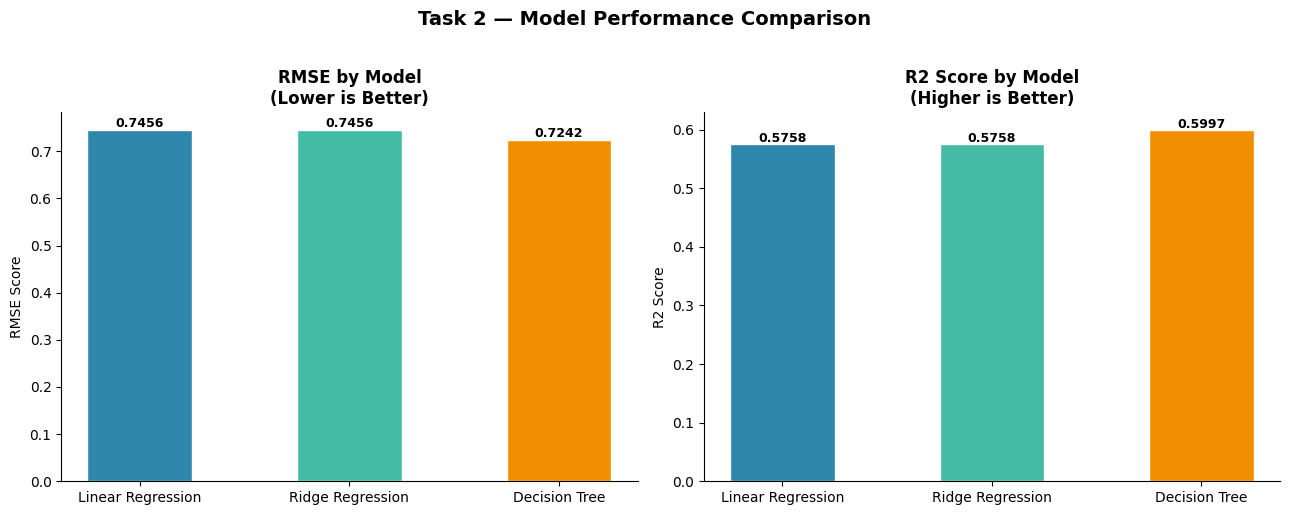

Bar chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(results_clean.keys())
rmse_scores = [results_clean[m]["RMSE"]     for m in model_names]
r2_scores   = [results_clean[m]["R2 Score"] for m in model_names]
colors      = ["#2E86AB", "#44BBA4", "#F18F01"]

# Plot 1: RMSE (lower is better)
bars1 = axes[0].bar(model_names, rmse_scores,
                    color=colors, edgecolor="white", width=0.5)
axes[0].set_title("RMSE by Model\n(Lower is Better)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("RMSE Score")
axes[0].spines[["top","right"]].set_visible(False)
for bar, val in zip(bars1, rmse_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

# Plot 2: R2 Score (higher is better)
bars2 = axes[1].bar(model_names, r2_scores,
                    color=colors, edgecolor="white", width=0.5)
axes[1].set_title("R2 Score by Model\n(Higher is Better)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("R2 Score")
axes[1].spines[["top","right"]].set_visible(False)
for bar, val in zip(bars2, r2_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Task 2 — Model Performance Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bar chart saved!")

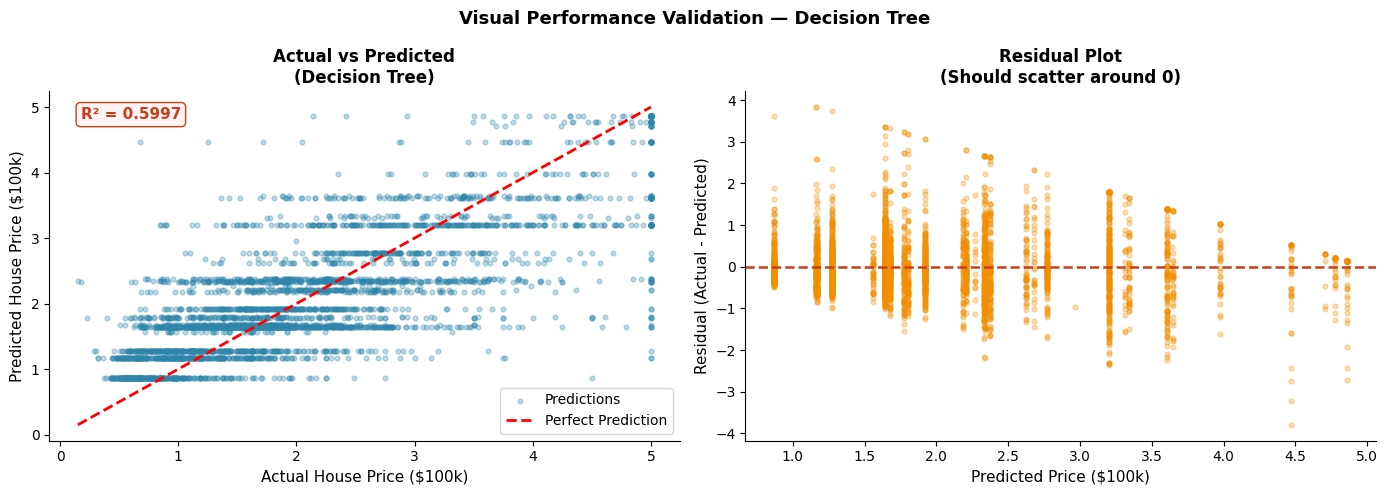

Scatter plots saved!


In [11]:
# Get best model predictions
best_preds = results[best_model_name]["Predictions"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.3,
                s=12, color="#2E86AB", label="Predictions")
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual House Price ($100k)", fontsize=11)
axes[0].set_ylabel("Predicted House Price ($100k)", fontsize=11)
axes[0].set_title(f"Actual vs Predicted\n({best_model_name})",
                  fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)
r2_val = results_clean[best_model_name]["R2 Score"]
axes[0].text(0.05, 0.92, f"R² = {r2_val}",
             transform=axes[0].transAxes, fontsize=11,
             color="#C73E1D", fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3",
                       facecolor="#fff3f3", edgecolor="#C73E1D"))

# Plot 2: Residual Plot
residuals = y_test.values - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.3,
                s=12, color="#F18F01")
axes[1].axhline(0, color="#C73E1D", linewidth=1.8, linestyle="--")
axes[1].set_xlabel("Predicted Price ($100k)", fontsize=11)
axes[1].set_ylabel("Residual (Actual - Predicted)", fontsize=11)
axes[1].set_title("Residual Plot\n(Should scatter around 0)",
                  fontsize=12, fontweight="bold")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(f"Visual Performance Validation — {best_model_name}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("actual_vs_predicted_task2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Scatter plots saved!")

In [12]:
import joblib

# Retrain best model on full training data
best_model_obj = models[best_model_name]
best_model_obj.fit(X_train, y_train)

# Save model and scaler together
joblib.dump(best_model_obj, "best_model_task2.pkl")
joblib.dump(scaler,         "scaler_task2.pkl")

print(f"Best model saved : best_model_task2.pkl")
print(f"Scaler saved     : scaler_task2.pkl")
print(f"Model saved      : {best_model_name}")

# How to load and use it later
print("\nTo use the model later:")
print("  model  = joblib.load('best_model_task2.pkl')")
print("  scaler = joblib.load('scaler_task2.pkl')")
print("  pred   = model.predict(scaler.transform(new_data))")

Best model saved : best_model_task2.pkl
Scaler saved     : scaler_task2.pkl
Model saved      : Decision Tree

To use the model later:
  model  = joblib.load('best_model_task2.pkl')
  scaler = joblib.load('scaler_task2.pkl')
  pred   = model.predict(scaler.transform(new_data))


In [13]:
print("=" * 55)
print("       TASK 2 COMPLETE — FINAL SUMMARY")
print("=" * 55)
print(f"\nDataset    : California Housing (20,640 rows)")
print(f"Features   : 8 input features, 1 target")
print(f"Train/Test : 80% / 20% split")
print(f"Scaling    : StandardScaler applied\n")

print("MODEL RESULTS:")
print("-" * 55)
for name, vals in results_clean.items():
    marker = " <-- BEST" if name == best_model_name else ""
    print(f"  {name:<22} R2={vals['R2 Score']:.4f}  "
          f"RMSE={vals['RMSE']:.4f}{marker}")

print("-" * 55)
print(f"\nSelected Model : {best_model_name}")
print(f"Reason         : Highest R2 and lowest RMSE on test data")
print(f"\nFiles saved:")
print(f"  - model_comparison_bar.png")
print(f"  - actual_vs_predicted_task2.png")
print(f"  - best_model_task2.pkl  (optional)")
print(f"  - scaler_task2.pkl      (optional)")
print("=" * 55)

       TASK 2 COMPLETE — FINAL SUMMARY

Dataset    : California Housing (20,640 rows)
Features   : 8 input features, 1 target
Train/Test : 80% / 20% split
Scaling    : StandardScaler applied

MODEL RESULTS:
-------------------------------------------------------
  Linear Regression      R2=0.5758  RMSE=0.7456
  Ridge Regression       R2=0.5758  RMSE=0.7456
  Decision Tree          R2=0.5997  RMSE=0.7242 <-- BEST
-------------------------------------------------------

Selected Model : Decision Tree
Reason         : Highest R2 and lowest RMSE on test data

Files saved:
  - model_comparison_bar.png
  - actual_vs_predicted_task2.png
  - best_model_task2.pkl  (optional)
  - scaler_task2.pkl      (optional)
